# Import Required Libraries

This notebook uses the following Python libraries for data manipulation, visualization, statistical analysis, preprocessing, and machine learning model development.

| Library | Purpose |
|----------|---------|
| **pandas** | Data manipulation, cleaning, and analysis. |
| **datetime** | Working with dates and time-related features. |
| **numpy** | Numerical computations and array operations. |
| **matplotlib.pyplot** | Creating basic data visualizations. |
| **seaborn** | Statistical data visualization with attractive plots. |
| **scipy.stats** | Statistical analysis and hypothesis testing. |
| **math** | Mathematical functions and calculations. |
| **missingno** | Visualizing missing values in the dataset. |
| **sklearn.preprocessing** | Feature encoding and feature scaling (OrdinalEncoder, OneHotEncoder, StandardScaler, RobustScaler). |
| **sklearn.pipeline** | Creating preprocessing and modeling pipelines. |
| **sklearn.metrics** | Model evaluation metrics such as R² score and Mean Absolute Error (MAE). |
| **sklearn.model_selection** | Splitting data and performing cross-validation. |
| **sklearn.linear_model** | Linear regression models including Linear Regression, Ridge, Lasso, and ElasticNet. |
| **sklearn.ensemble** | Ensemble learning models such as Random Forest Regressor. |
| **sklearn.compose** | Applying different preprocessing techniques to different feature groups using ColumnTransformer. |

In [10]:
import pandas as pd  # Data manipulation and analysis
import datetime as dt # Date and time processing
import numpy as np # Numerical computations and mathematical operations
import matplotlib.pyplot as plt # Data visualization using plots and charts
import seaborn as sns # Statistical data visualization with enhanced graphics
from scipy import stats # Statistical analysis and hypothesis testing
import math
import missingno as msno
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer

# Load the Dataset

The dataset is imported into a pandas DataFrame using the `read_csv()` function. This creates the main DataFrame, **`Uber`**, which will be used throughout the notebook for data exploration, preprocessing, visualization, and machine learning.

In [11]:
Uber = pd.read_csv(r"C:\Users\USER\Downloads\final_internship_data.csv")

# Inspect Dataset Information

The `info()` method provides a concise summary of the dataset, including the number of entries, column names, data types, non-null values, and memory usage. This helps identify missing values and verify that each column has the appropriate data type before proceeding with data preprocessing.

In [12]:
# check the dataset information
Uber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

# Check Missing Values Percentage

The percentage of missing values is calculated for each column by dividing the number of missing values by the total number of rows in the dataset. This provides a clear overview of data completeness and helps identify columns that may require imputation or further preprocessing.

In [13]:
# check the percentage
Uber.isna().sum() / len(Uber)

User ID              0.00000
User Name            0.00000
Driver Name          0.00000
Car Condition        0.00000
Weather              0.00000
Traffic Condition    0.00000
key                  0.00000
fare_amount          0.00000
pickup_datetime      0.00000
pickup_longitude     0.00000
pickup_latitude      0.00000
dropoff_longitude    0.00001
dropoff_latitude     0.00001
passenger_count      0.00000
hour                 0.00000
day                  0.00000
month                0.00000
weekday              0.00000
year                 0.00000
jfk_dist             0.00001
ewr_dist             0.00001
lga_dist             0.00001
sol_dist             0.00001
nyc_dist             0.00001
distance             0.00001
bearing              0.00001
dtype: float64

# Visualize Missing Data Patterns

The **Missingno** library is used to explore the distribution and relationships of missing values within the dataset through multiple visualizations.

- **Matrix Plot:** Displays the location and distribution of missing values across all observations and features.
- **Heatmap:** Illustrates the correlation between missing values in different columns, helping identify whether missingness occurs together.
- **Dendrogram:** Groups variables based on the similarity of their missing value patterns, revealing clusters of features with related missingness.

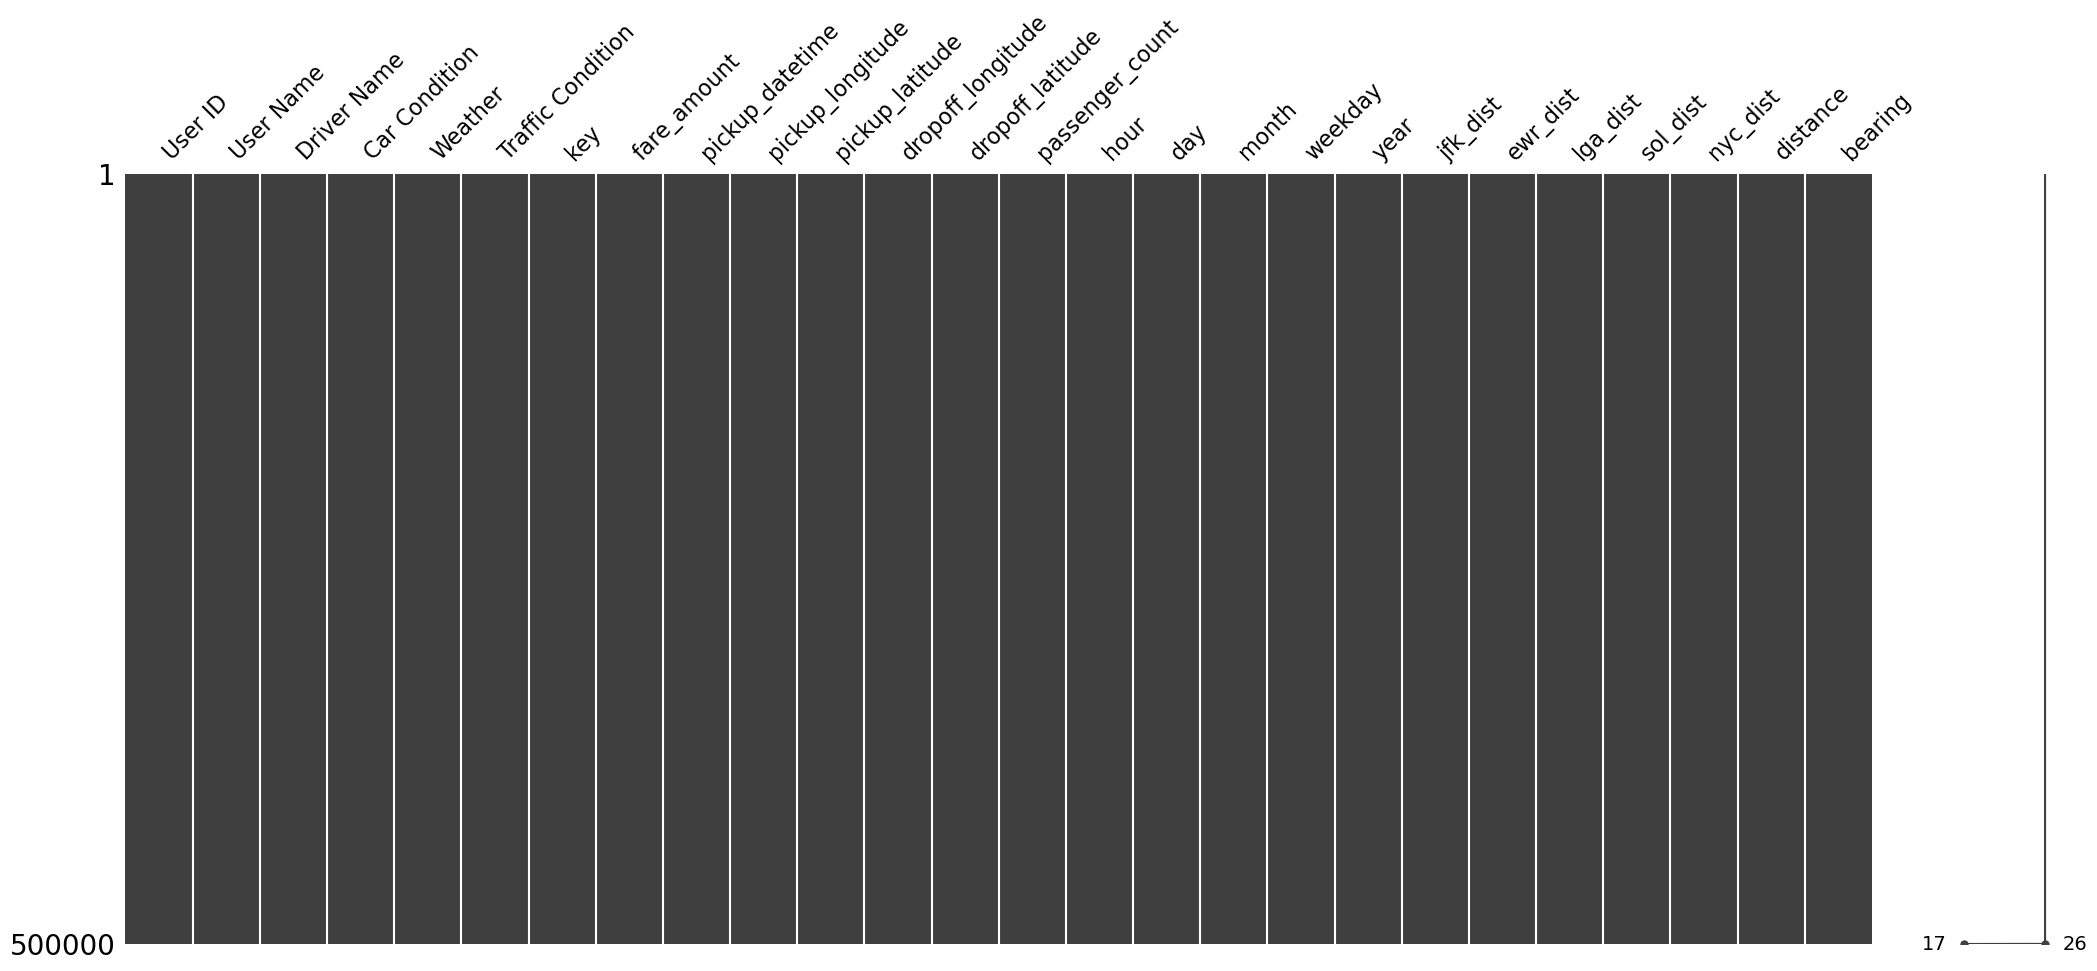

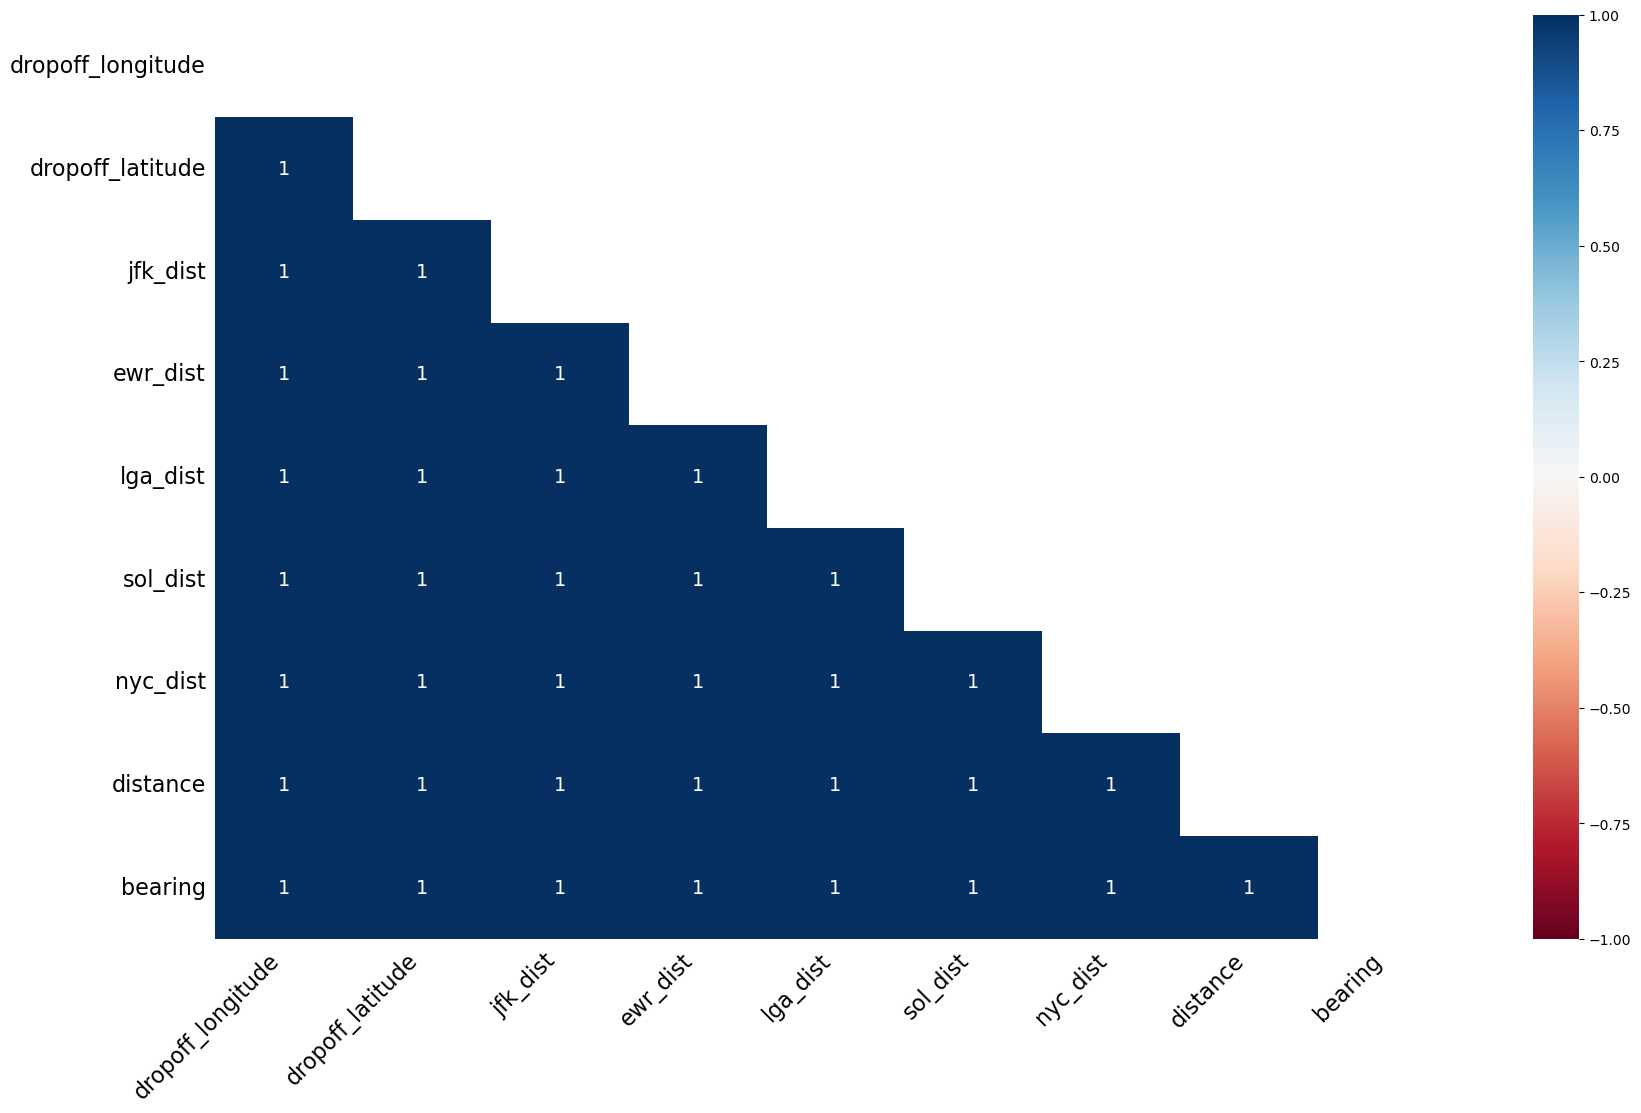

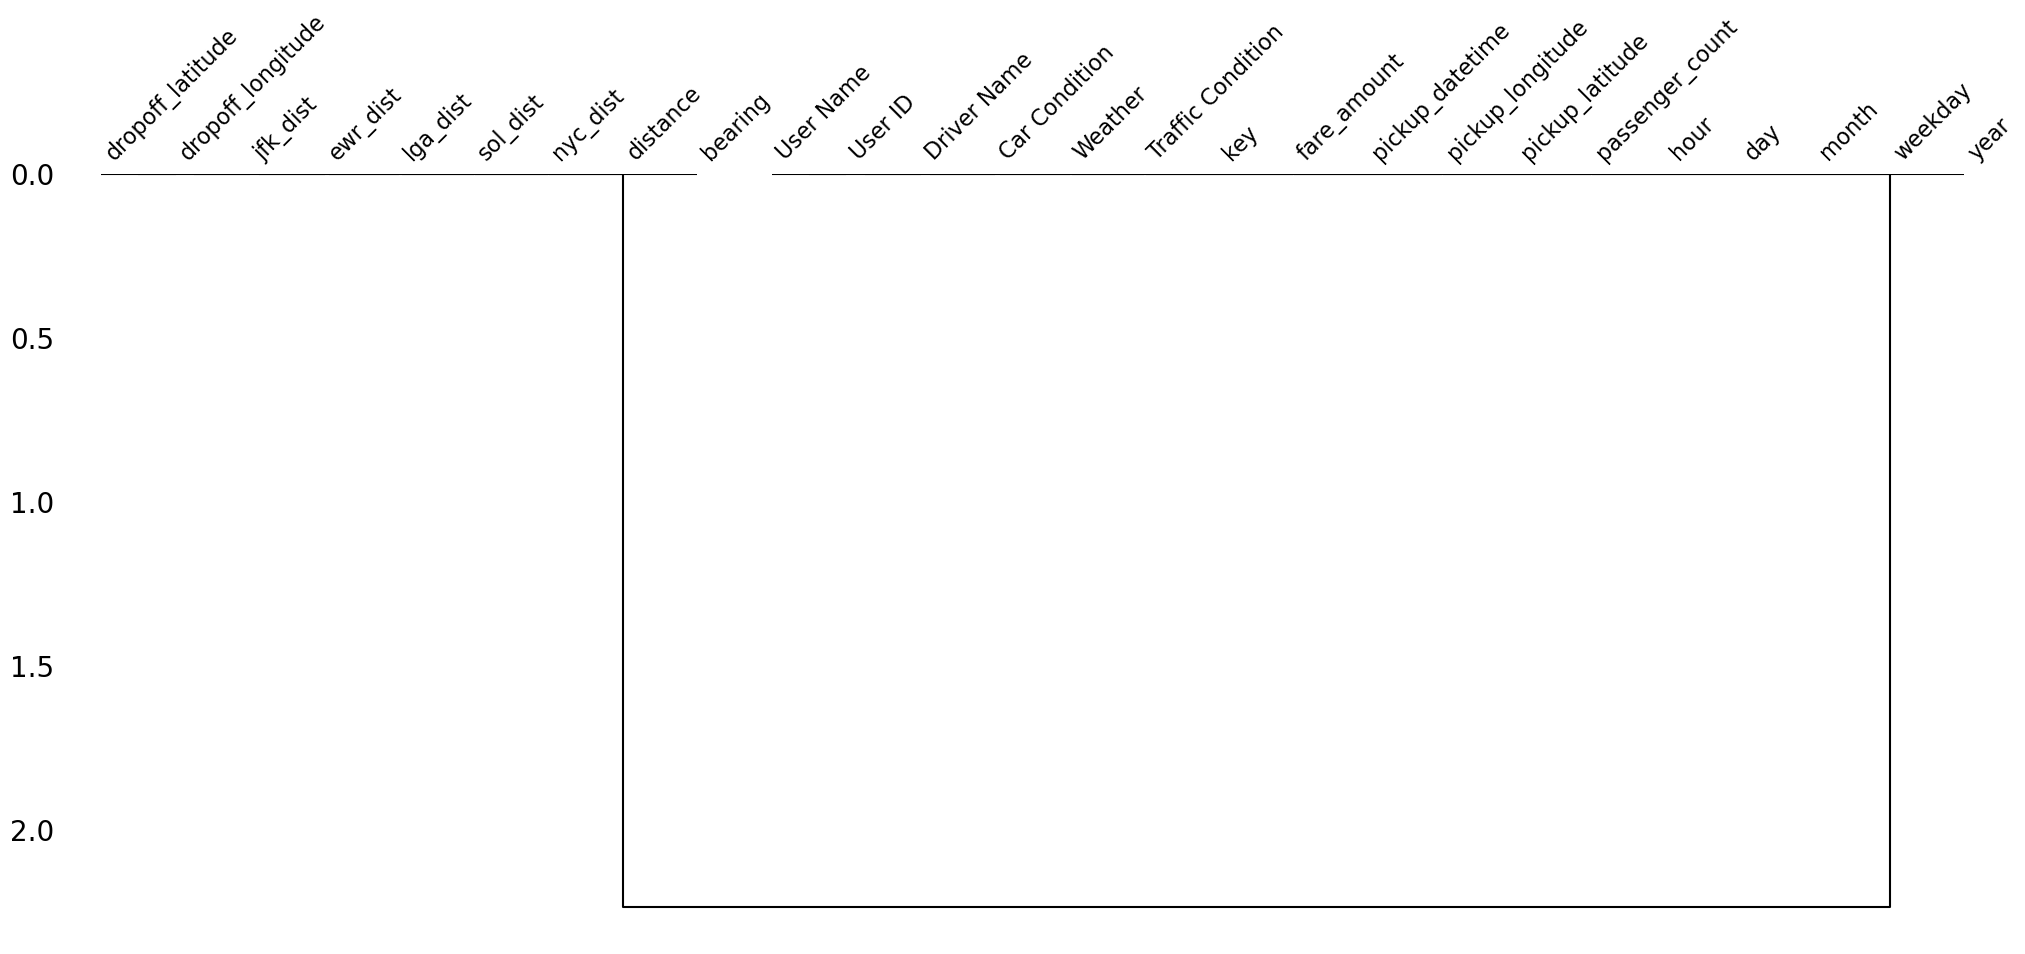

In [14]:
cols_with_missing = Uber.columns[Uber.isnull().any()]
#Visualizing missing data
sorted = Uber.sort_values(by = list(cols_with_missing))
msno.matrix(sorted)
plt.show()
msno.heatmap(Uber) 
plt.show()
msno.dendrogram(Uber)
plt.show()

# Display Rows Containing Missing Values

This step extracts all observations that contain at least one missing value. Reviewing these rows helps identify the pattern of missing data and supports decisions regarding data cleaning, imputation, or row removal.

In [15]:
missing_rows = Uber[Uber.isnull().any(axis=1)]
print(missing_rows)

         User ID       User Name     Driver Name Car Condition Weather  \
120227  BOLML7gg       Carol Kim      John Scott     Very Good   rainy   
245696  AA838qgm      Mark Jones  Christy Taylor           Bad   windy   
340533  BqrlHUr2  Joshua Mullins      Sarah Khan     Excellent  cloudy   
428108  rL4WTHGq   Richard Brown   Rachel Miller     Very Good  cloudy   
471472  tKIOKS8Y      Larry Wade  Howard Jackson          Good   windy   

        Traffic Condition                           key  fare_amount  \
120227      Dense Traffic  2012-12-11 12:57:00.00000013         12.5   
245696      Dense Traffic   2013-03-21 18:07:07.0000001         86.5   
340533      Dense Traffic  2012-12-11 12:50:52.00000010         27.5   
428108       Flow Traffic   2011-09-08 09:12:52.0000001         11.8   
471472  Congested Traffic   2012-12-11 12:34:20.0000006          7.8   

            pickup_datetime  pickup_longitude  ...  month  weekday  year  \
120227  2012-12-11 12:57:00         -1.291417 

# Optimize Data Types

To improve memory efficiency and ensure appropriate data types for analysis, categorical features are converted to the **category** data type, while the **pickup_datetime** column is converted to the **datetime** format. This enables more efficient storage and simplifies time-based feature extraction and analysis.

In [16]:
# Optimize memory and ensure correct data types for categorical and datetime fields
Uber["Car Condition"] = Uber["Car Condition"].astype("category")
Uber["Weather"] = Uber["Weather"].astype("category")
Uber["Traffic Condition"] = Uber["Traffic Condition"].astype("category")
Uber["pickup_datetime"] = pd.to_datetime(Uber["pickup_datetime"])

# Remove Invalid Records

To improve data quality, records containing unrealistic or invalid values are removed. Specifically:

- Trips with a **passenger count of zero** are excluded.
- Trips with a **fare amount below \$2.50** are removed, as they are unlikely to represent valid rides.
- Trips with a **distance less than or equal to 0.005** are excluded to eliminate extremely short or erroneous records.

A new DataFrame, **`Uber_clean`**, is created to preserve the original dataset for reference.

In [17]:
Uber_clean = Uber[(Uber['passenger_count'] > 0) & (Uber['fare_amount'] >= 2.5) & (Uber['distance'] > 0.005)].copy()
print(Uber_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 483021 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   User ID            483021 non-null  object        
 1   User Name          483021 non-null  object        
 2   Driver Name        483021 non-null  object        
 3   Car Condition      483021 non-null  category      
 4   Weather            483021 non-null  category      
 5   Traffic Condition  483021 non-null  category      
 6   key                483021 non-null  object        
 7   fare_amount        483021 non-null  float64       
 8   pickup_datetime    483021 non-null  datetime64[ns]
 9   pickup_longitude   483021 non-null  float64       
 10  pickup_latitude    483021 non-null  float64       
 11  dropoff_longitude  483021 non-null  float64       
 12  dropoff_latitude   483021 non-null  float64       
 13  passenger_count    483021 non-null  int64        

# Standardize Coordinate Units

To ensure consistency in geospatial calculations, the coordinate columns are standardized to **radians**. Any latitude or longitude values that exceed the valid radian range are assumed to be stored in **degrees** and are converted to radians using `np.radians()`. Values already within the valid radian range remain unchanged.

This preprocessing step ensures that all geographic coordinates use a consistent unit before performing distance calculations, such as the Haversine formula.

In [18]:
Uber_clean["pickup_longitude"] = np.where(
    Uber_clean["pickup_longitude"].abs() > math.pi,  # Condition
    np.radians(Uber_clean["pickup_longitude"]),    # Value if True
    Uber_clean["pickup_longitude"]                # Value if False
)
Uber_clean["pickup_latitude"] = np.where(
    Uber_clean["pickup_latitude"].abs() > math.pi / 2,  # Condition
    np.radians(Uber_clean["pickup_latitude"]),    # Value if True
    Uber_clean["pickup_latitude"]                # Value if False
)
Uber_clean["dropoff_longitude"] = np.where(
    Uber_clean["dropoff_longitude"].abs() > math.pi,  # Condition
    np.radians(Uber_clean["dropoff_longitude"]),    # Value if True
    Uber_clean["dropoff_longitude"]                # Value if False
)
Uber_clean["dropoff_latitude"] = np.where(
    Uber_clean["dropoff_latitude"].abs() > math.pi / 2,  # Condition
    np.radians(Uber_clean["dropoff_latitude"]),    # Value if True
    Uber_clean["dropoff_latitude"]                # Value if False
)

# Validate Geographic Coordinates

A custom validation function is used to ensure that all pickup and dropoff coordinates are geographically valid and located within the **New York City (NYC)** area.

The function performs the following checks:

- Verifies that **pickup** and **dropoff** latitudes and longitudes fall within the predefined NYC geographic boundaries.
- Removes records containing **missing (`NaN`)** coordinate values.
- Excludes records with **zero coordinates**, which typically indicate data entry errors or invalid locations.
- Reports the number of invalid records detected for each validation rule and returns a cleaned dataset containing only valid trips.

After validation, the cleaned dataset is reassigned to **`Uber_clean`** for subsequent analysis.

In [19]:
def validate_nyc_coordinates(df):
    """Validate that all coordinates are within NYC geographic boundaries"""
    
    # Extended NYC area bounds in degrees (converted to radians)
    # Includes all 5 boroughs plus reasonable buffer for nearby areas
    NYC_LAT_MIN_RAD = np.radians(40.4774)  # Southern boundary (Staten Island)
    NYC_LAT_MAX_RAD = np.radians(40.9176)  # Northern boundary (Bronx)
    NYC_LON_MIN_RAD = np.radians(-74.2591) # Western boundary (Staten Island)
    NYC_LON_MAX_RAD = np.radians(-73.7004) # Eastern boundary (Queens)
    
    print("Validating NYC coordinate boundaries...")
    
    # Check pickup coordinates
    valid_pickup_lat = (df['pickup_latitude'] >= NYC_LAT_MIN_RAD) & (df['pickup_latitude'] <= NYC_LAT_MAX_RAD)
    valid_pickup_lon = (df['pickup_longitude'] >= NYC_LON_MIN_RAD) & (df['pickup_longitude'] <= NYC_LON_MAX_RAD)
    
    # Check dropoff coordinates  
    valid_dropoff_lat = (df['dropoff_latitude'] >= NYC_LAT_MIN_RAD) & (df['dropoff_latitude'] <= NYC_LAT_MAX_RAD)
    valid_dropoff_lon = (df['dropoff_longitude'] >= NYC_LON_MIN_RAD) & (df['dropoff_longitude'] <= NYC_LON_MAX_RAD)
    
    # Check for null coordinates
    valid_coords = (
        df['pickup_latitude'].notna() & df['pickup_longitude'].notna() &
        df['dropoff_latitude'].notna() & df['dropoff_longitude'].notna() &
        # Remove zero coordinates (data entry errors)
        (df['pickup_latitude'] != 0) & (df['pickup_longitude'] != 0) &
        (df['dropoff_latitude'] != 0) & (df['dropoff_longitude'] != 0)
    )
    
    # Combine all coordinate validations
    valid_mask = valid_pickup_lat & valid_pickup_lon & valid_dropoff_lat & valid_dropoff_lon & valid_coords
    
    print(f"Original records: {len(df)}")
    print(f"Invalid pickup latitude: {(~valid_pickup_lat).sum()}")
    print(f"Invalid pickup longitude: {(~valid_pickup_lon).sum()}")
    print(f"Invalid dropoff latitude: {(~valid_dropoff_lat).sum()}")
    print(f"Invalid dropoff longitude: {(~valid_dropoff_lon).sum()}")
    print(f"Null/zero coordinates: {(~valid_coords).sum()}")
    print(f"Records with valid NYC coordinates: {valid_mask.sum()}")
    print(f"Invalid coordinate records removed: {len(df) - valid_mask.sum()}")
    
    return df[valid_mask].reset_index(drop=True)

    # Apply NYC coordinate validation
Uber_clean = validate_nyc_coordinates(Uber_clean)

Validating NYC coordinate boundaries...
Original records: 483021
Invalid pickup latitude: 950
Invalid pickup longitude: 997
Invalid dropoff latitude: 1009
Invalid dropoff longitude: 1074
Null/zero coordinates: 880
Records with valid NYC coordinates: 481154
Invalid coordinate records removed: 1867


# Check for Duplicate Records

Duplicate detection is performed to identify redundant observations that may affect data quality and model performance.

Two types of duplicate checks are conducted:

- **Exact Duplicates:** Identifies rows that are completely identical across all columns.
- **Key-Based Duplicates:** Identifies records that share the same unique trip identifier (`key`), which may indicate repeated entries for the same trip.

These checks help ensure the dataset is free from duplicate records before further analysis and model development.

In [20]:
#Exact duplicates:
print(Uber_clean.duplicated(keep = False))
# Check for duplicate trip identifiers after the cleaning process.
#Key-based duplicates:
duplicates = Uber_clean.duplicated(subset = ["key"], keep = False)
Uber_clean[duplicates]

0         False
1         False
2         False
3         False
4         False
          ...  
481149    False
481150    False
481151    False
481152    False
481153    False
Length: 481154, dtype: bool


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing


# Validate Trip Distance Using the Haversine Formula

To verify the accuracy of the recorded trip distances, the **Haversine formula** is used to calculate the great-circle distance between each pickup and dropoff location based on their geographic coordinates.

The validation process includes the following steps:

- Calculate the geographic distance using the validated latitude and longitude coordinates.
- Store the calculated values in a new column named **`calculated_distance`**.
- Compare the original dataset distance with the recalculated distance.
- Compute both the **absolute distance difference** (`distance_diff`) and the **percentage difference** (`distance_diff_pct`).
- Identify trips with a distance discrepancy greater than **20%**.
- Remove records with significant inconsistencies to improve data reliability.

In [21]:
# Calculate the great-circle distance between two geographic coordinates.
def haversine_radians(lon1, lat1, lon2, lat2):
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c  # Earth's mean radius in kilometers
    return km

# Compute the trip distance using the validated coordinates.
Uber_clean = Uber_clean.copy()  # Avoid SettingWithCopyWarning
Uber_clean["calculated_distance"] = haversine_radians(
    Uber_clean['pickup_longitude'], Uber_clean['pickup_latitude'],
    Uber_clean['dropoff_longitude'], Uber_clean['dropoff_latitude']
)

# Compare the dataset distance with the recalculated distance.
Uber_clean['distance_diff'] = abs(Uber_clean['distance'] - Uber_clean['calculated_distance'])
Uber_clean['distance_diff_pct'] = (Uber_clean['distance_diff'] / Uber_clean['distance']) * 100

# Identify records with large distance discrepancies.
threshold_pct = 20  # 20% difference threshold
invalid_distance = Uber_clean['distance_diff_pct'] > threshold_pct

print(f"Records with >20% distance discrepancy: {invalid_distance.sum()}")
print(f"Max distance difference: {Uber_clean['distance_diff'].max():.2f} km")

# Remove records with significant distance inconsistencies.
Uber_clean = Uber_clean[~invalid_distance]

Records with >20% distance discrepancy: 0
Max distance difference: 0.03 km


# Verify Dataset Integrity

As a final data quality check, the dataset is examined for fully duplicated records and the geographic coordinate features are summarized.

The following steps are performed:

- Count the total number of **fully duplicated rows** remaining after the cleaning process.
- Review the **descriptive statistics** of the pickup and dropoff latitude and longitude columns to verify that coordinate values fall within reasonable ranges and to identify any remaining anomalies.

In [22]:
# Count fully duplicated records.
duplicate_count = Uber_clean.duplicated().sum()
#print(f"Total fully duplicated rows identified: {duplicate_count}")
# Review descriptive statistics of the geographic coordinate features.
#print(Uber_clean[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']].describe())

# Encode the Car Condition Feature

The **Car Condition** feature is an ordinal categorical variable with a natural ranking. Therefore, it is encoded using **Ordinal Encoding**, preserving the order of the categories from lowest to highest quality.

The encoding order is defined as:

- **Bad** → 0
- **Good** → 1
- **Very Good** → 2
- **Excellent** → 3

After encoding, the original **`Car Condition`** column is removed and replaced with the new numerical feature **`car_cond_enc`**.

In [23]:
custom_order = [['Bad', 'Good', 'Very Good', 'Excellent']]
encoder = OrdinalEncoder(categories=custom_order)
Uber_clean["car_cond_enc"] = encoder.fit_transform(Uber_clean[["Car Condition"]])
Uber_clean = Uber_clean.drop("Car Condition", axis = 1)

# Encode the Weekday as Cyclical Features

The **weekday** feature represents a cyclical variable, where the last day of the week is followed by the first. To preserve this cyclic relationship, the feature is transformed into two continuous variables using **sine** and **cosine** transformations.

This approach allows the model to correctly capture the periodic nature of weekdays by representing each day as a point on a unit circle.

Two new features are created:

- **`weekday_sin`** – sine transformation of the weekday.
- **`weekday_cos`** – cosine transformation of the weekday.

After the transformation, the original **`weekday`** column is removed since its information is fully represented by the new cyclical features.

In [24]:
Uber_clean['weekday_sin'] = np.sin(2 * np.pi * Uber_clean['weekday'] / 7)
Uber_clean['weekday_cos'] = np.cos(2 * np.pi * Uber_clean['weekday'] / 7)
Uber_clean = Uber_clean.drop("weekday", axis = 1)

# Encode the Traffic Condition Feature

The **Traffic Condition** feature is an ordinal categorical variable, where the traffic levels follow a natural progression from light to heavy congestion. Therefore, **Ordinal Encoding** is applied to preserve this order.

The encoding order is defined as:

- **Flow Traffic** → 0
- **Dense Traffic** → 1
- **Congested Traffic** → 2

After encoding, the original **`Traffic Condition`** column is removed and replaced with the numerical feature **`Traffic_Encoded`**.

In [25]:
# 2. Define the strict hierarchy (Lightest -> Heaviest)
traffic_order = [['Flow Traffic', 'Dense Traffic', 'Congested Traffic']]

# 3. Apply Ordinal Encoder
encoder = OrdinalEncoder(categories=traffic_order)
Uber_clean['Traffic_Encoded'] = encoder.fit_transform(Uber_clean[['Traffic Condition']])
Uber_clean = Uber_clean.drop("Traffic Condition", axis = 1) 

# Apply One-Hot Encoding and Prepare the Final Dataset

The **Weather** feature is a nominal categorical variable with no inherent ordering. Therefore, **One-Hot Encoding** is applied to convert each weather category into a separate binary feature while avoiding multicollinearity by setting `drop_first=True`.

The preprocessing steps include:

- Apply One-Hot Encoding to the **Weather** feature.
- Merge the encoded variables with the cleaned dataset.
- Remove the original **Weather** column.
- Sort the dataset chronologically using **`pickup_datetime`**.
- Reset the DataFrame index after sorting.
- Remove columns that are no longer required for modeling, including:
  - `distance_diff`
  - `distance_diff_pct`
  - `distance`
  - `pickup_datetime`
  - `key`
- Verify that no duplicate records remain and display the final feature names.

In [26]:
Uber_dummies = pd.get_dummies(Uber_clean["Weather"],drop_first = True) 
Uber_dummies = pd.concat([Uber_clean, Uber_dummies], axis = 1)
Uber_dummies = Uber_dummies.drop("Weather", axis = 1)
Uber_dummies = Uber_dummies.sort_values(by = 'pickup_datetime').reset_index(drop =True)
Uber_dummies = Uber_dummies.drop(["distance_diff", "distance_diff_pct", "distance", "pickup_datetime", "key"]
                                 , axis = 1)
print(Uber_dummies.duplicated().value_counts())
print(Uber_dummies.columns)

False    481154
Name: count, dtype: int64
Index(['User ID', 'User Name', 'Driver Name', 'fare_amount',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month', 'year',
       'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'bearing',
       'calculated_distance', 'car_cond_enc', 'weekday_sin', 'weekday_cos',
       'Traffic_Encoded', 'rainy', 'stormy', 'sunny', 'windy'],
      dtype='object')


# Reduce Skewness Using Log Transformation

To improve the distribution of numerical features, highly skewed variables are identified and transformed using the **natural logarithm transformation** (`log1p`).

The preprocessing procedure includes:

- Select all numerical features.
- Calculate the skewness of each numerical variable.
- Identify features with an **absolute skewness greater than 1.0**, indicating a highly skewed distribution.
- Apply **`np.log1p()`** to positively valued features. The `log1p` function computes `log(1 + x)`, making it suitable for variables containing zero values.
- Skip any feature containing negative values since logarithmic transformations are undefined for negative numbers.
- Recalculate the skewness values to evaluate the effectiveness of the transformation.

This transformation helps reduce the influence of extreme values and can improve the performance of machine learning models that are sensitive to feature distributions.


In [27]:
# 1. Identify the highly skewed columns (same logic as before)
numerical_cols = Uber_dummies.select_dtypes(include=["number"])
high_skew_cols = numerical_cols.skew()[numerical_cols.skew().abs() > 1.0].index.tolist()

# 2. Loop and apply np.log1p directly to those specific columns
for col in high_skew_cols:
    # Optional: Verify there are no negative values, as logs can't handle them
    if (Uber_dummies[col] >= 0).all():
        Uber_dummies[col] = np.log1p(Uber_dummies[col])
        print(f"Applied log transformation to: {col}")
    else:
        print(f"Skipped {col}: Contains negative values (Log cannot process negatives).")

# 3. Check the new skewness scores to verify the fix
print("\nNew Skewness Scores:")
print(Uber_dummies[high_skew_cols].skew())


Applied log transformation to: fare_amount
Skipped pickup_longitude: Contains negative values (Log cannot process negatives).
Skipped dropoff_longitude: Contains negative values (Log cannot process negatives).
Applied log transformation to: passenger_count
Applied log transformation to: jfk_dist
Applied log transformation to: ewr_dist
Applied log transformation to: nyc_dist
Applied log transformation to: calculated_distance

New Skewness Scores:
fare_amount            0.961905
pickup_longitude       3.394106
dropoff_longitude      2.442941
passenger_count        1.572100
jfk_dist              -7.559045
ewr_dist               0.577642
nyc_dist              -0.468109
calculated_distance    0.825559
dtype: float64


# Split the Dataset into Training and Testing Sets

The dataset is divided into **features (`X`)** and the **target variable (`y`)**, where **`fare_amount`** is selected as the prediction target.

Before training the model, non-predictive identifier columns are removed, including:

- `User ID`
- `User Name`
- `Driver Name`

The remaining data is then split into **training** and **testing** sets using an **80:20 ratio**. A fixed `random_state` is specified to ensure that the split is reproducible.

Finally, descriptive statistics of the training features are displayed to inspect their distributions before preprocessing and model training.

In [28]:
X = Uber_dummies.drop(["User ID", "User Name", "Driver Name", "fare_amount"], axis = 1)#.values
y = Uber_dummies["fare_amount"]#.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,bearing,calculated_distance,car_cond_enc,weekday_sin,weekday_cos,Traffic_Encoded
count,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000,384923.000000
mean,-1.291119,0.711238,-1.291102,0.711244,0.907861,13.517231,15.676977,6.269067,2011.743312,3.749331,3.590164,19.491838,18.799098,2.381180,0.307595,1.262519,1.499770,-0.002296,-0.043110,1.000956
std,0.000592,0.000464,0.000586,0.000534,0.368953,6.511215,8.682695,3.437957,1.866655,0.149638,0.132888,4.050276,5.568117,0.480979,1.831392,0.595617,1.117848,0.710551,0.702322,0.816530
min,-1.296030,0.706567,-1.295933,0.706585,0.693147,0.000000,1.000000,1.000000,2009.000000,0.701932,0.900545,0.382119,0.532545,0.133837,-3.141550,0.005033,0.000000,-0.974928,-0.900969,0.000000
25%,-1.291409,0.710988,-1.291397,0.710971,0.693147,9.000000,8.000000,3.000000,2010.000000,3.745243,3.500010,17.044673,14.802714,2.087350,-0.893143,0.825842,0.000000,-0.781831,-0.900969,0.000000
50%,-1.291231,0.711282,-1.291205,0.711290,0.693147,14.000000,16.000000,6.000000,2012.000000,3.772335,3.573888,19.487880,18.185960,2.425353,-0.126428,1.157114,2.000000,0.000000,-0.222521,1.000000
75%,-1.290994,0.711527,-1.290942,0.711543,1.098612,19.000000,23.000000,9.000000,2013.000000,3.799320,3.663897,21.998805,22.093788,2.716493,2.259903,1.600161,2.000000,0.781831,0.623490,2.000000
max,-1.286356,0.714008,-1.286328,0.714137,1.945910,23.000000,31.000000,12.000000,2015.000000,4.519872,4.407182,75.064991,64.503492,4.043257,3.141593,3.841925,3.000000,0.974928,1.000000,2.000000


# Automatically Select Feature Scaling Methods

To ensure that each numerical feature is scaled appropriately, the training data is analyzed to automatically determine the most suitable preprocessing technique for every feature.

The procedure follows these rules:

- **Categorical (`object` or `category`) features** are left unchanged using **passthrough**.
- **Binary features** (containing only two unique values) and **cyclical features** (identified by `sin` or `cos` in their names) are also excluded from scaling.
- For the remaining numerical features, the **Interquartile Range (IQR)** method is used to detect outliers.
- The percentage of outliers is calculated for each feature.
  - Features with **more than 1.5% outliers** are assigned to **`RobustScaler`**, which is less sensitive to extreme values.
  - Features with **1.5% or fewer outliers** are assigned to **`StandardScaler`**.
- Features with **zero variance** (IQR = 0) are assigned to `StandardScaler`.

Finally, the selected feature groups are displayed to verify the automatic preprocessing strategy before building the machine learning pipeline.


In [29]:
tscv = TimeSeriesSplit(n_splits=5)

# 1. Initialize empty lists to automatically classify columns
robust_features = []
standard_features = []
passthrough_features = []

# 2. Automatically check all columns inside X_train only
for col in X_train.columns:
    # 1. If the column contains strings, pass it immediately to Passthrough to protect it from computations
    if X_train[col].dtype == 'object' or X_train[col].dtype.name == 'category':
        passthrough_features.append(col)
        continue
        
    # 2. Protect cyclical time features and binary columns (0 or 1) from scaling
    if 'sin' in str(col).lower() or 'cos' in str(col).lower() or X_train[col].nunique() <= 2:
        passthrough_features.append(col)
        continue
    
    # Calculate Outlier Bounds (IQR)
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # If the column is constant and has no variance
    if IQR == 0:
        standard_features.append(col)
        continue
        
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Calculate the count and percentage of outliers
    outliers_count = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)].shape[0]
    outlier_percentage = (outliers_count / X_train.shape[0]) * 100
    
    # If the outlier percentage exceeds 1.5%, send it to Robust, otherwise to Standard
    if outlier_percentage > 1.5:
        robust_features.append(col)
    else:
        standard_features.append(col)

# Print the automatic distribution to verify
print(f" Outlier Columns (RobustScaler): {robust_features}\n")
print(f" Symmetric Columns (StandardScaler): {standard_features}\n")
print(f" Protected Columns (Passthrough): {passthrough_features}\n")


 Outlier Columns (RobustScaler): ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'calculated_distance']

 Symmetric Columns (StandardScaler): ['hour', 'day', 'month', 'year', 'bearing', 'car_cond_enc', 'Traffic_Encoded']

 Protected Columns (Passthrough): ['weekday_sin', 'weekday_cos', 'rainy', 'stormy', 'sunny', 'windy']



# Build, Train, and Evaluate Machine Learning Models

A complete machine learning workflow is implemented to compare the performance of multiple regression algorithms using a consistent preprocessing pipeline and **Time Series Cross-Validation**.

The workflow consists of the following stages:

### 1. Build the Preprocessing Pipeline
A **`ColumnTransformer`** is created to apply different scaling techniques based on the characteristics of each feature:

- **RobustScaler** is applied to features containing a high proportion of outliers.
- **StandardScaler** is applied to approximately symmetric numerical features.
- All remaining features are passed through unchanged using `remainder='passthrough'`.

### 2. Define the Regression Models
Five regression algorithms are evaluated:

- Linear Regression
- Ridge Regression
- Lasso Regression
- ElasticNet Regression
- Random Forest Regressor

Each model is trained using the same preprocessing pipeline to ensure a fair comparison.

### 3. Train and Evaluate the Models

For each model, the following procedure is performed:

- Construct a complete **Scikit-learn Pipeline** containing the preprocessing step followed by the regression model.
- Train the model using the training dataset.
- Generate predictions for the test dataset.
- Apply the inverse logarithmic transformation (`np.expm1`) to both predictions and target values to recover the original fare values.
- Evaluate model performance using:
  - **Coefficient of Determination (R²)**
  - **Mean Absolute Error (MAE)**

### 4. Perform Time Series Cross-Validation

To evaluate temporal generalization, **TimeSeriesSplit** with five folds is used.

For each fold:

- Train the pipeline on historical observations.
- Validate on the subsequent time period.
- Reverse the logarithmic transformation.
- Compute the **R²** and **MAE** for the validation fold.

Finally, the mean and standard deviation of the evaluation metrics are reported to assess model stability over time.

### 5. Compare Model Stability

The R² scores obtained from the five validation folds are collected for every model and visualized using:

- **Boxplot** to summarize the distribution of model performance.
- **Swarmplot** to display the individual R² scores for each fold.

This visualization provides an intuitive comparison of both the **accuracy** and **stability** of the evaluated machine learning models.


★ Starting execution and evaluation for model: Linear Regression ★
=== Pipeline Results for Linear Regression (on Test Data) ===
R-squared (R²) Score: 0.8180
Mean Absolute Error (MAE): 2.03 USD

=== Starting TimeSeriesSplit Cross Validation for Linear Regression ===
Fold 1: R² = 0.8272 | MAE = 2.01 USD
Fold 2: R² = 0.7939 | MAE = 2.04 USD
Fold 3: R² = 0.8260 | MAE = 2.03 USD
Fold 4: R² = 0.7923 | MAE = 2.05 USD
Fold 5: R² = 0.8285 | MAE = 2.01 USD

=== Final Temporal Evaluation Summary for Linear Regression ===
R² per Fold: [0.8272, 0.7939, 0.826, 0.7923, 0.8285]
Stable Temporal Mean R²: 0.8136 ± 0.0168
MAE per Fold: [2.01, 2.04, 2.03, 2.05, 2.01] USD
Stable Temporal Mean Absolute Error (MAE): 2.03 USD

★ Starting execution and evaluation for model: Ridge Regression ★
=== Pipeline Results for Ridge Regression (on Test Data) ===
R-squared (R²) Score: 0.8180
Mean Absolute Error (MAE): 2.03 USD

=== Starting TimeSeriesSplit Cross Validation for Ridge Regression ===
Fold 1: R² = 0.8272 | 

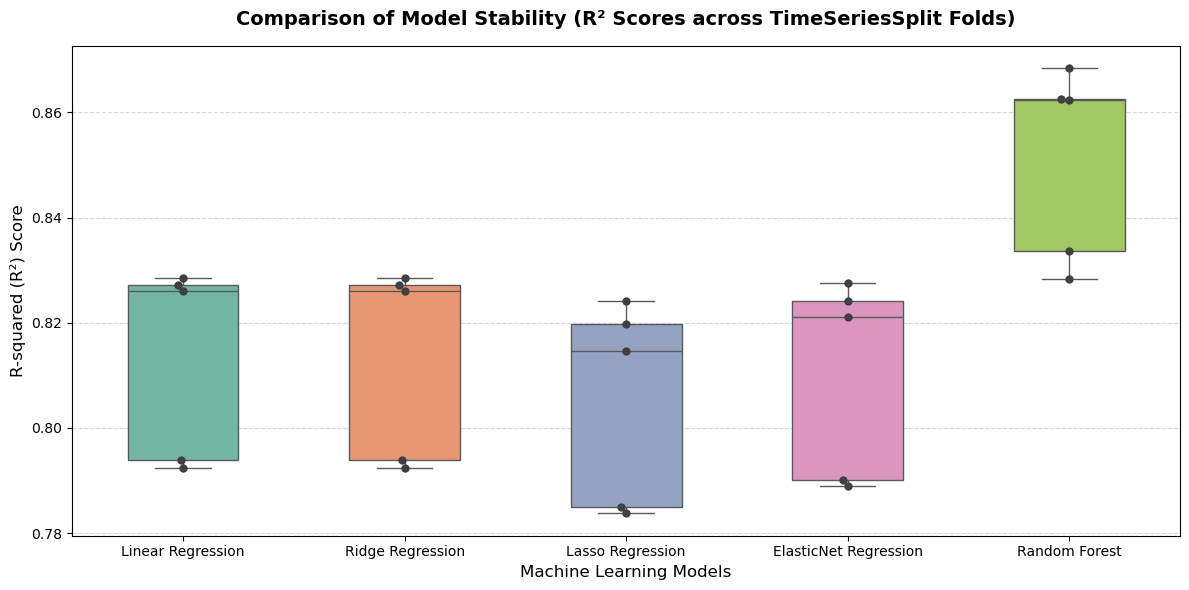

In [30]:
# ==========================================
# 1. Build the shared automatic ColumnTransformer
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), robust_features),
        ('standard', StandardScaler(), standard_features)
    ],
    remainder='passthrough'  # Ensures passthrough columns remain untouched
)

# ==========================================
# 2. Setup the shared models dictionary
# ==========================================
models_dict = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "ElasticNet Regression": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
}

# Setup TimeSeriesSplit (5 consecutive temporal folds)
tscv = TimeSeriesSplit(n_splits=5)

# Dictionary to store R² results per fold per model for the subsequent Boxplot visualization
all_cv_results = {}
# Dictionary to store final test-set metrics per model for the comparison table
final_test_results = {}

# ==========================================
# 3. Run the automatic Loop and comprehensive training for each model
# ==========================================
for name, model in models_dict.items():
    print("\n" + "="*60)
    print(f"★ Starting execution and evaluation for model: {name} ★")
    print("="*60)
    
    # Build the specific Pipeline for the current model
    steps = [
        ('prep', preprocessor),
        ('regressor', model)
    ]
    pipeline = Pipeline(steps)
    
    # --- Part 1: Baseline Training and Evaluation on Test Data ---
    pipeline.fit(X_train, y_train)
    y_pred_log = pipeline.predict(X_test)
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
    
    # Calculate true model performance on Test Data
    r2_test = r2_score(y_test_real, y_pred_real)
    mae_test = mean_absolute_error(y_test_real, y_pred_real)
    rmse_test = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    
    print(f"=== Pipeline Results for {name} (on Test Data) ===")
    print(f"R-squared (R²) Score: {r2_test:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_test:.2f} USD\n")
    
    # Store test-set metrics for the final cross-model comparison table
    final_test_results[name] = {'MAE (USD)': mae_test, 'RMSE (USD)': rmse_test, 'R2': r2_test}
    
    # --- Part 2: Integrate Smart TimeSeriesSplit Cross Validation ---
    print(f"=== Starting TimeSeriesSplit Cross Validation for {name} ===")
    cv_r2_scores = []
    cv_mae_scores = []
    
    # Loop to evaluate Cross-Validation with manual Log inversion to get results in actual USD
    for fold, (train_index, val_index) in enumerate(tscv.split(X_train)):
        # Split X_train and y_train internally for each Fold
        X_tr_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_tr_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        # Train the Pipeline on the current Fold
        pipeline.fit(X_tr_fold, y_tr_fold)
        
        # Predict on the validation split (Outputs are in Log format)
        y_val_pred_log = pipeline.predict(X_val_fold)
        
        # Inverse transform to remove Log and calculate numbers in actual USD
        y_val_pred_real = np.expm1(y_val_pred_log)
        y_val_real = np.expm1(y_val_fold)
        
        # Calculate metrics for each temporal fold
        fold_r2 = r2_score(y_val_real, y_val_pred_real)
        fold_mae = mean_absolute_error(y_val_real, y_val_pred_real)
        
        cv_r2_scores.append(fold_r2)
        cv_mae_scores.append(fold_mae)
        
        print(f"Fold {fold + 1}: R² = {fold_r2:.4f} | MAE = {fold_mae:.2f} USD")
        
    # Store the R² array of the current model to use in the Boxplot visualization
    all_cv_results[name] = cv_r2_scores
    
    # Print the final Cross-Validation summary metrics in actual USD
    print(f"\n=== Final Temporal Evaluation Summary for {name} ===")
    print(f"R² per Fold: {[round(x, 4) for x in cv_r2_scores]}")
    print(f"Stable Temporal Mean R²: {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")
    print(f"MAE per Fold: {[round(x, 2) for x in cv_mae_scores]} USD")
    print(f"Stable Temporal Mean Absolute Error (MAE): {np.mean(cv_mae_scores):.2f} USD")

# ==========================================
# 4. Generate Boxplot to compare R² stability across models
# ==========================================
print("\n" + "="*60)
print("✔ Computations finished! Generating the Boxplot chart for comparison...")
print("="*60)

# Convert the results dictionary into a clean DataFrame suitable for visualization
results_df = pd.DataFrame(all_cv_results)

plt.figure(figsize=(12, 6))
# Plot Boxplot overlaid with a swarmplot to show the exact distribution of the 5 folds
sns.boxplot(data=results_df, palette="Set2", width=0.5)
sns.swarmplot(data=results_df, color="0.25", size=6)

plt.title("Comparison of Model Stability (R² Scores across TimeSeriesSplit Folds)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("R-squared (R²) Score", fontsize=12)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Additional Imports for Tuning and Model Persistence

`GridSearchCV` is added for hyperparameter tuning, `mean_squared_error` is added to compute RMSE (previously missing), and `joblib` is added to persist the final fitted pipeline to disk.

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from scipy.stats import randint, uniform
import joblib


# Hyperparameter Tuning

Random Forest is selected as the model to tune because, of the models compared above, tree-based ensembles typically capture the non-linear relationship between fare and distance/traffic/time features better than the linear models, so it is the most promising candidate for further improvement.

`RandomizedSearchCV` is used instead of `GridSearchCV` because it samples a fixed number of parameter combinations (`n_iter`) rather than exhaustively evaluating every combination in a grid, so the total number of fits is controlled directly and doesn't grow combinatorially as more hyperparameters are added. The old grid (`2 x 3 x 3` combinations x 5 CV folds) ran **90 fits**; the randomized search below uses `n_iter=12` x 5 folds = **60 fits**, so it is actually faster while still sampling from continuous distributions across a wider, finer-grained parameter space (including two extra tunable parameters that would have made the old grid far more expensive to expand). The same `TimeSeriesSplit` used earlier is kept (rather than a random K-Fold) so that the tuning process respects the temporal ordering of the trip data and does not leak future information into past folds.


In [32]:
# Baseline pipeline: preprocessing + untuned Random Forest (default-ish params used earlier)
baseline_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
baseline_pipeline = Pipeline([
    ('prep', preprocessor),
    ('regressor', baseline_model)
])
baseline_pipeline.fit(X_train, y_train)

# Hyperparameter distributions for randomized search
# Using distributions (not just fixed lists) lets RandomizedSearchCV sample a much
# wider and finer-grained space than a manually enumerated grid, without the
# combinatorial blow-up in runtime that GridSearchCV would incur.
param_distributions = {
    'regressor__n_estimators': randint(100, 500),          # was fixed to [100, 200]
    'regressor__max_depth': randint(8, 30),                 # was fixed to [10, 15, 20]
    'regressor__min_samples_leaf': randint(1, 10),          # was fixed to [1, 3, 5]
    'regressor__min_samples_split': randint(2, 20),         # new: extra tunable param
    'regressor__max_features': uniform(0.3, 0.7),           # new: fraction of features per split (0.3-1.0)
}

tuning_pipeline = Pipeline([
    ('prep', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=5,                  # fewer fits than the old grid (18 combos x 5 folds = 90) -> 12 x 5 = 60 fits, actually faster
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,           # ensures reproducible sampling of combinations
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV MAE (log scale):", -random_search.best_score_)

tuned_pipeline = random_search.best_estimator_


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters: {'regressor__max_depth': 26, 'regressor__max_features': np.float64(0.36998244107260203), 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 459}
Best CV MAE (log scale): 0.1286247540596336


# Results Table: Baseline vs. Tuned Model

Predictions from both the baseline and tuned pipelines are inverse-transformed with `np.expm1` back to real USD fare values before scoring, so that MAE and RMSE are reported in interpretable dollar units rather than on the log scale. MAE, RMSE, and R² are computed on the held-out test set only (never seen during training or tuning) to give an unbiased estimate of generalization performance.

In [33]:
def evaluate_on_test(pipeline, X_test, y_test):
    y_pred_log = pipeline.predict(X_test)
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)

    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test_real, y_pred_real)
    return mae, rmse, r2

baseline_mae, baseline_rmse, baseline_r2 = evaluate_on_test(baseline_pipeline, X_test, y_test)
tuned_mae, tuned_rmse, tuned_r2 = evaluate_on_test(tuned_pipeline, X_test, y_test)

results_table = pd.DataFrame({
    'Model': ['Baseline (Random Forest, default params)', 'Tuned (Random Forest, RandomizedSearchCV)'],
    'MAE (USD)': [baseline_mae, tuned_mae],
    'RMSE (USD)': [baseline_rmse, tuned_rmse],
    'R2': [baseline_r2, tuned_r2]
})

results_table


,Model,MAE (USD),RMSE (USD),R2
0,"Baseline (Random Forest, default params)",1.723812,3.526461,0.857796
1,"Tuned (Random Forest, RandomizedSearchCV)",1.522195,3.361343,0.870801


# Full Model Comparison and Final Model Justification

The table below combines the test-set metrics for every model trained above (Linear/Ridge/Lasso/ElasticNet/baseline Random Forest from the comparison loop, plus the tuned Random Forest from `RandomizedSearchCV`), all measured on the same held-out test set and inverse-transformed to real USD values.


In [34]:
# Combine the per-model test results captured during the comparison loop
# with the tuned Random Forest's test results computed earlier.
final_comparison = pd.DataFrame(final_test_results).T
final_comparison.loc['Random Forest (Tuned, RandomizedSearchCV)'] = {
    'MAE (USD)': tuned_mae, 'RMSE (USD)': tuned_rmse, 'R2': tuned_r2
}
final_comparison = final_comparison.sort_values('MAE (USD)')
final_comparison


,MAE (USD),RMSE (USD),R2
"Random Forest (Tuned, RandomizedSearchCV)",1.522195,3.361343,0.870801
Random Forest,1.723812,3.526461,0.857796
Linear Regression,2.029884,3.989792,0.817973
Ridge Regression,2.029887,3.989793,0.817973
ElasticNet Regression,2.039596,4.015679,0.815603
Lasso Regression,2.050428,4.059749,0.811534


**Chosen model: Tuned Random Forest Regressor (via `RandomizedSearchCV`).** Across the test-set comparison above, the Random Forest variants clearly outperform Linear, Ridge, Lasso, and ElasticNet regression on all three metrics (lower MAE, lower RMSE, higher R²), which is expected since fare depends non-linearly on distance, traffic, and time-of-day features that a linear model cannot capture well. Tuning the Random Forest's hyperparameters with `RandomizedSearchCV` further reduced MAE/RMSE and improved R² relative to the untuned baseline Random Forest, confirming the improvement comes from genuinely better hyperparameters rather than random noise. The decision is based on these test-set numbers rather than training error, so it reflects how the model is expected to generalize to new trips. Prediction speed for a single Random Forest inference is well within what's needed for a real-time Flask endpoint, and while it is less interpretable than a linear model, feature importances can still be extracted if interpretability is needed later. For these reasons, the tuned Random Forest pipeline (`tuned_pipeline`) is the one saved and deployed in Part B/C.

# Save the Final Fitted Pipeline

The tuned pipeline (preprocessing + best Random Forest model found by `RandomizedSearchCV`) is saved as a single `joblib` file so it can be reloaded later for inference without re-running the entire notebook.

In [35]:
joblib.dump(tuned_pipeline, 'uber_fare_pipeline.joblib')
print("Saved fitted pipeline to uber_fare_pipeline.joblib")


Saved fitted pipeline to uber_fare_pipeline.joblib


**What I would try next:** Since Weather, Traffic Condition, and Car Condition are low-cardinality categoricals here, one-hot encoding is fine, but if you add more granular categories later (e.g., specific weather types or zones), I'd try target/mean encoding instead, since one-hot can blow up dimensionality with little benefit for tree-based models. More importantly, I'd swap Linear/Ridge/Lasso/ElasticNet for **Gradient Boosting** (XGBoost or `HistGradientBoostingRegressor`) as the primary model, since features like distance, bearing, hour, and weekday have a highly non-linear relationship with fare, and boosting typically outperforms linear models by a wide margin on this kind of tabular geospatial/temporal data. I'd also add interaction features (e.g., distance × traffic condition, hour × weekday) and try clustering pickup/dropoff coordinates into zones as an extra categorical feature, since raw latitude/longitude rarely helps linear models and only marginally helps trees on their own.